# Random state

Generating Clifford-based 2-design...

Generating random circuit-based approximate 2-design...

Verifying Clifford 2-design:
Expected purity for 2-design: 0.222222
Measured average purity: 0.137625 ± 0.140022
Relative error: 38.07%

Verifying random circuit 2-design:
Expected purity for 2-design: 0.222222
Measured average purity: 0.127765 ± 0.130201
Relative error: 42.51%


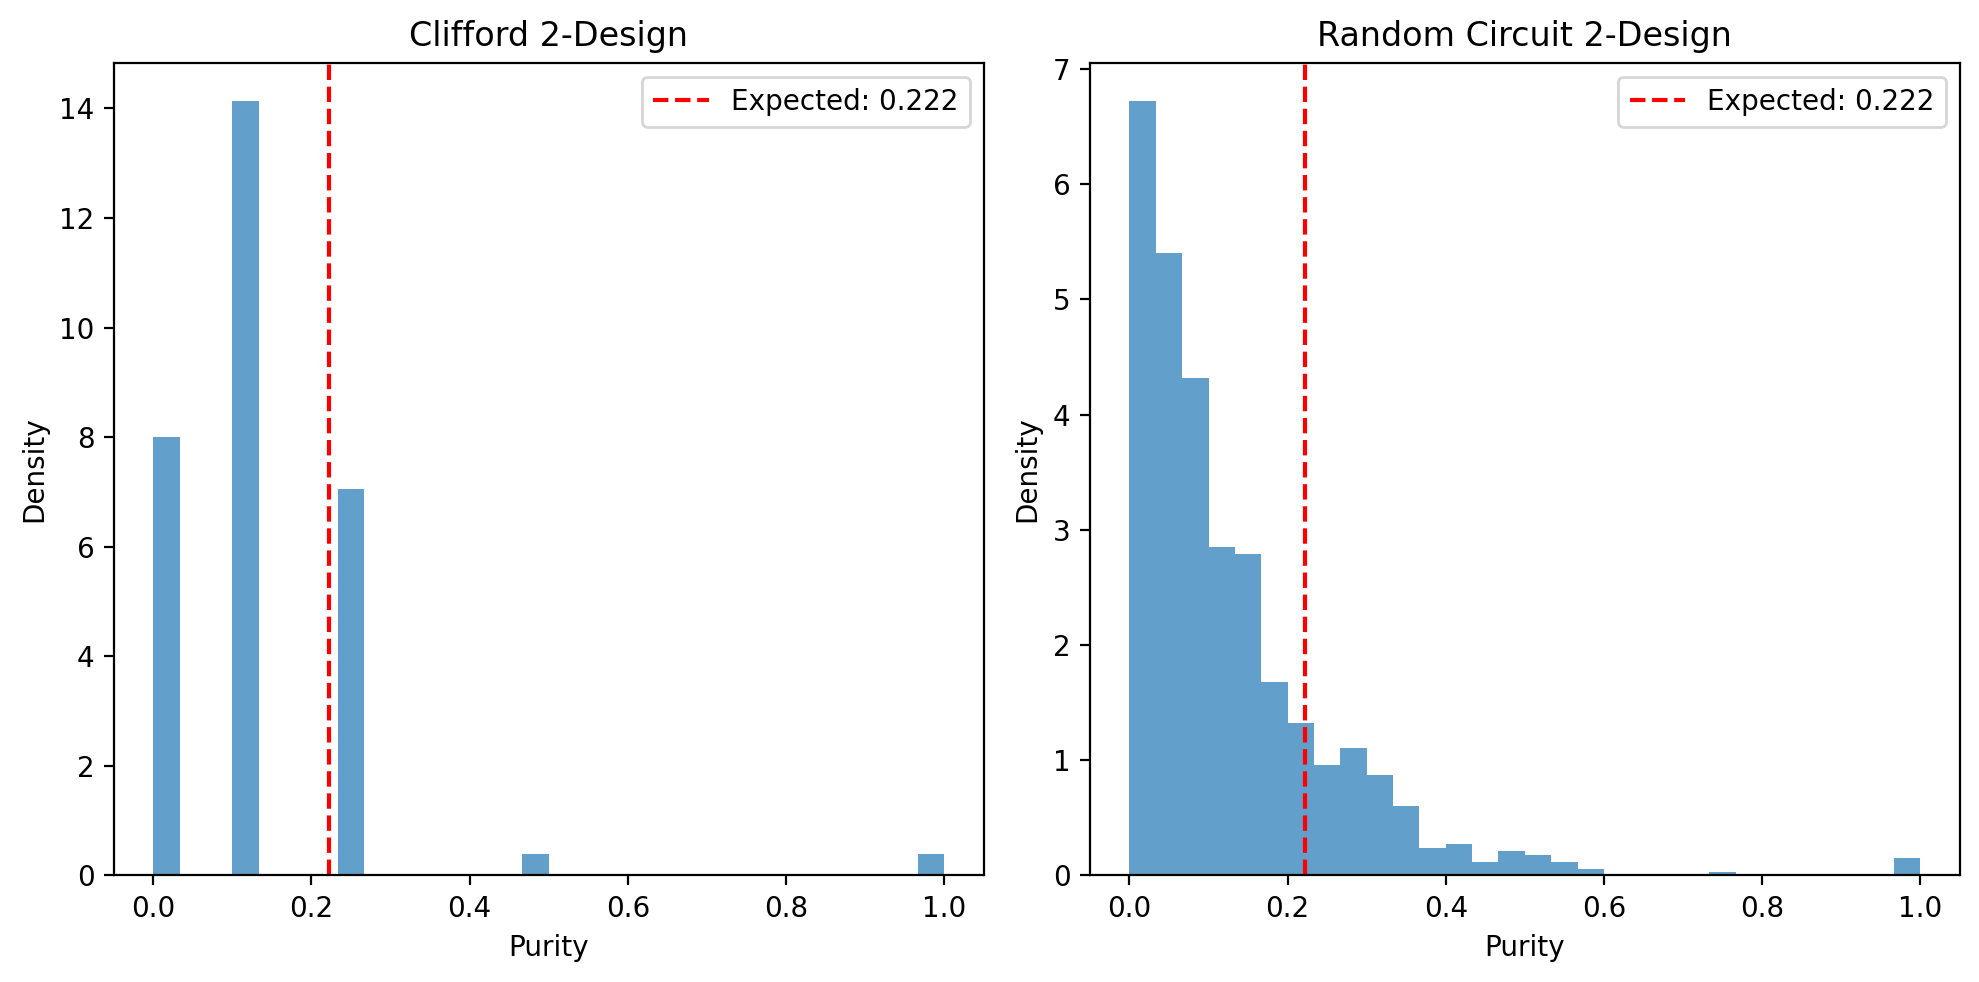


Example state from 2-design:
State vector shape: (8,)
First few amplitudes: [-0.5-4.45093965e-18j -0.5+4.45093965e-18j -0.5-4.45093965e-18j
 -0.5+4.45093965e-18j]


In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Clifford, Statevector, random_clifford
from qiskit.circuit.library import PauliGate
import matplotlib.pyplot as plt

def generate_clifford_2_design(n_qubits, n_states):
    """
    Generate a 2-design using random Clifford states.
    
    Args:
        n_qubits: Number of qubits
        n_states: Number of states to generate
        
    Returns:
        List of Statevector objects
    """
    states = []
    
    for _ in range(n_states):
        # Generate a random Clifford operator
        cliff = random_clifford(n_qubits)
        
        # Create a circuit and apply the Clifford
        qc = QuantumCircuit(n_qubits)
        qc.append(cliff.to_circuit(), range(n_qubits))
        
        # Get the state vector (applied to |0...0⟩)
        state = Statevector.from_instruction(qc)
        states.append(state)
    
    return states

def generate_random_circuit_2_design(n_qubits, n_states, depth=None):
    """
    Generate approximate 2-design using random quantum circuits.
    
    Args:
        n_qubits: Number of qubits
        n_states: Number of states to generate
        depth: Circuit depth (default: O(n_qubits²) for good approximation)
        
    Returns:
        List of Statevector objects
    """
    if depth is None:
        depth = n_qubits * n_qubits
    
    states = []
    
    # Define gate set for random circuits
    single_qubit_gates = ['rx', 'ry', 'rz']
    
    for _ in range(n_states):
        qc = QuantumCircuit(n_qubits)
        
        for d in range(depth):
            # Random single-qubit gates
            for qubit in range(n_qubits):
                gate = np.random.choice(single_qubit_gates)
                angle = np.random.uniform(0, 2*np.pi)
                getattr(qc, gate)(angle, qubit)
            
            # Entangling gates (CZ gates on neighboring qubits)
            if d % 2 == 0:
                for qubit in range(0, n_qubits-1, 2):
                    qc.cz(qubit, qubit+1)
            else:
                for qubit in range(1, n_qubits-1, 2):
                    qc.cz(qubit, qubit+1)
        
        state = Statevector.from_instruction(qc)
        states.append(state)
    
    return states

def verify_2_design_property(states, n_samples=1000):
    """
    Verify the 2-design property by checking second moments.
    For a true 2-design, the purity should be approximately 1/(2^n + 1)
    """
    n_qubits = states[0].num_qubits
    d = 2**n_qubits
    expected_purity = 2 / (d + 1)  # Expected for 2-design
    
    # Sample random pairs and compute average purity
    purities = []
    for _ in range(n_samples):
        i, j = np.random.choice(len(states), 2, replace=True)
        overlap = np.abs(states[i].inner(states[j]))**2
        purities.append(overlap)
    
    avg_purity = np.mean(purities)
    std_purity = np.std(purities)
    
    print(f"Expected purity for 2-design: {expected_purity:.6f}")
    print(f"Measured average purity: {avg_purity:.6f} ± {std_purity:.6f}")
    print(f"Relative error: {abs(avg_purity - expected_purity)/expected_purity:.2%}")
    
    return purities

# Example usage
n_qubits = 3
n_states = 100

# Method 1: Clifford-based 2-design
print("Generating Clifford-based 2-design...")
clifford_states = generate_clifford_2_design(n_qubits, n_states)

# Method 2: Random circuit approximation
print("\nGenerating random circuit-based approximate 2-design...")
circuit_states = generate_random_circuit_2_design(n_qubits, n_states)

# Verify the 2-design property
print("\nVerifying Clifford 2-design:")
cliff_purities = verify_2_design_property(clifford_states)

print("\nVerifying random circuit 2-design:")
circ_purities = verify_2_design_property(circuit_states)

# Visualize the distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(cliff_purities, bins=30, alpha=0.7, density=True)
plt.axvline(2/(2**n_qubits + 1), color='r', linestyle='--', 
            label=f'Expected: {2/(2**n_qubits + 1):.3f}')
plt.xlabel('Purity')
plt.ylabel('Density')
plt.title('Clifford 2-Design')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(circ_purities, bins=30, alpha=0.7, density=True)
plt.axvline(2/(2**n_qubits + 1), color='r', linestyle='--',
            label=f'Expected: {2/(2**n_qubits + 1):.3f}')
plt.xlabel('Purity')
plt.ylabel('Density')
plt.title('Random Circuit 2-Design')
plt.legend()

plt.tight_layout()
plt.show()

# Generate a specific state from the 2-design for further use
example_state = clifford_states[0]
print(f"\nExample state from 2-design:")
print(f"State vector shape: {example_state.data.shape}")
print(f"First few amplitudes: {example_state.data[:4]}")